<a href="https://colab.research.google.com/github/estyaprnm/Analisis-Deret-waktu/blob/main/praktikum%20minggu%20kedua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

#Asumsi dari regresi

normal,homogen,saling bebas (tidak terjadi autokorelasi),acak, linear.
maksud dari linear ini adalah konstan naik atau kosntan turun jadinya gak beraturan makanya acak

ada pola siklik atau berulang(musiman) ini adalah pola teratur artinya dia berulang di waktu tertentu contohnnya kanyak curah hujan

kalau trend itu pola nya naik terus atau turun terus

Kalau multivariate itu ada X nya, KALAU GAK ADA X NYA BERARTI UNIVARIATE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [4]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1058) #NIM saya M0501251058
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 29   # 0.5 * 58
beta0 = 68  # 10 + 58
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


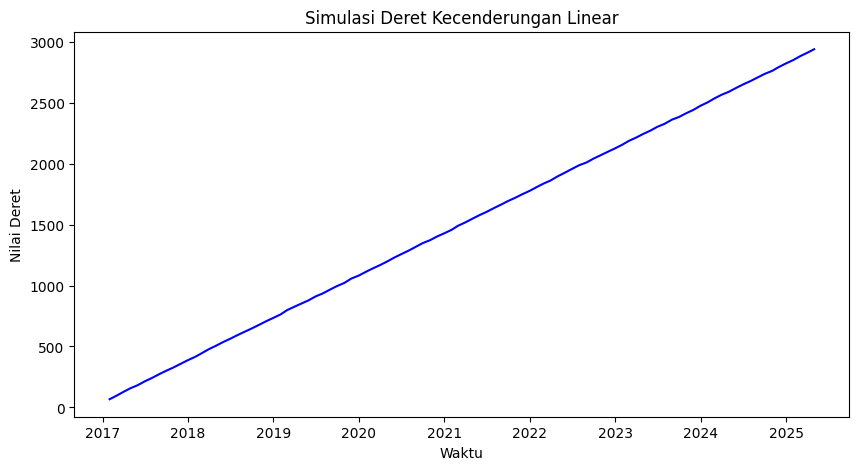

In [5]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

**Cek apakah ada korelasi antar pengamatan?**

Berdasarkan hasil simulasi, deret waktu menunjukkan adanya korelasi positif antar pengamatan karena nilai meningkat secara konsisten mengikuti perubahan waktu. Hal ini menunjukkan adanya ketergantungan antar periode yang dipengaruhi oleh komponen tren. Pola grafik yang membentuk garis kenaikan yang stabil menunjukkan bahwa perubahan nilai pada setiap periode memiliki hubungan yang kuat dengan periode sebelumnya.

Nilai β₁ (koefisien tren) sangat memengaruhi pola grafik. Nilai β₁ sebesar 29 menyebabkan peningkatan nilai deret menjadi lebih cepat sehingga pola tren terlihat lebih dominan dan membentuk garis yang semakin meningkat. Ketika β₁ bernilai besar, perubahan nilai setiap periode menjadi lebih tinggi sehingga pengaruh noise relatif kecil dibandingkan dengan komponen tren. Hal ini menunjukkan bahwa semakin besar nilai β₁, semakin kuat pengaruh tren linear terhadap data dan semakin jelas pola hubungan antar pengamatan.

In [6]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [7]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.534e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.37e-256
Time:                        13:39:15   Log-Likelihood:                -216.81
No. Observations:                 100   AIC:                             437.6
Df Residuals:                      98   BIC:                             442.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           68.6845      0.424    161.928   

**Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai
parameter asli?**

Hasil estimasi regresi sangat mendekati nilai parameter asli. Parameter awal yang digunakan adalah β₀ = 68 dan β₁ = 29, sedangkan hasil regresi menghasilkan β₀ = 68,6845 dan β₁ = 28,9887. Perbedaan nilai yang kecil menunjukkan bahwa model regresi mampu mengestimasi parameter asli dengan baik dan sesuai dengan pola tren linear yang dibangkitkan.

**Apakah model regresi yang dipaskan sudah bagus?**
Model regresi yang dipaskan sudah sangat baik, ditunjukkan oleh nilai R-squared = 1,000, yang berarti hampir seluruh variasi data dapat dijelaskan oleh hubungan linear dengan waktu. Selain itu, nilai p-value koefisien β₁ < 0,05 menunjukkan bahwa tren waktu berpengaruh signifikan terhadap nilai deret. Dengan demikian, model regresi linear sudah mampu menggambarkan pola kenaikan data secara akurat.

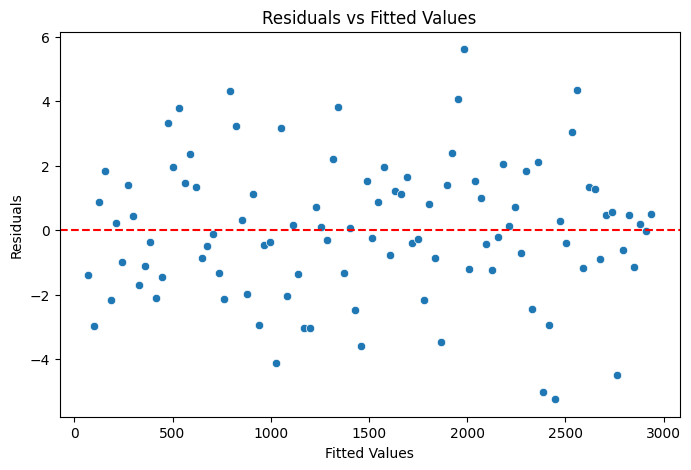

In [8]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


**Apa interpretasi dari plot tersebut?**

Plot menunjukkan bahwa residual tersebar secara acak di sekitar garis nol tanpa membentuk pola tertentu. Hal ini mengindikasikan bahwa model regresi mampu menangkap pola tren linear dengan baik dan tidak terdapat pola sistematis pada kesalahan prediksi.

Selain itu, penyebaran residual terlihat relatif merata pada berbagai nilai fitted values, sehingga tidak menunjukkan adanya indikasi kuat masalah heteroskedastisitas. Dengan demikian, model regresi dapat dikatakan sudah cukup baik dalam menjelaskan hubungan antara waktu dan nilai deret.

In [10]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.5430


**Apa kesimpulan dari nilai uji Breusch Pagan tersebut?**

Hasil uji Breusch-Pagan menunjukkan nilai p-value = 0,5430. Karena nilai p-value lebih besar dari tingkat signifikansi α = 0,05, maka gagal menolak H₀.

Artinya, tidak terdapat bukti adanya masalah heteroskedastisitas pada residual model. Varians residual dapat dianggap konstan (homoskedastis), sehingga asumsi regresi linear terkait kesamaan varians error telah terpenuhi. Dengan demikian, model regresi yang digunakan sudah layak untuk menjelaskan hubungan antara waktu dan nilai deret.

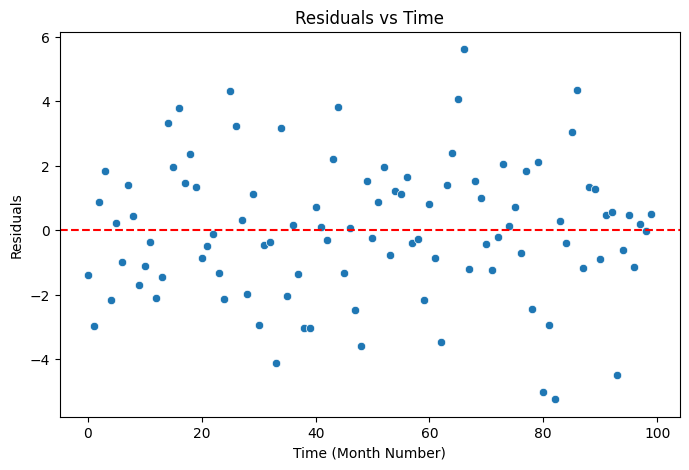

In [12]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

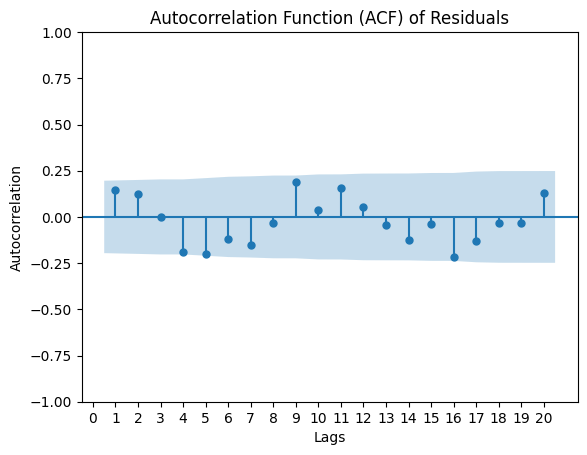

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


**Apa yang dapat Anda simpulkan dari plot di atas?**

Berdasarkan plot residual terhadap waktu, terlihat bahwa residual tersebar secara acak di sekitar garis nol tanpa menunjukkan pola tertentu. Hal ini menunjukkan bahwa residual tidak memiliki kecenderungan meningkat atau menurun berdasarkan waktu, sehingga tidak terdapat pola sistematis dalam kesalahan model.


Selain itu, hasil plot ACF residual menunjukkan bahwa sebagian besar nilai autokorelasi berada dalam batas interval kepercayaan. Hal ini mengindikasikan bahwa residual tidak memiliki korelasi yang signifikan antar periode. Dengan demikian, residual dapat dianggap bersifat acak (white noise) dan model regresi yang digunakan sudah mampu menangkap pola utama pada data deret waktu.

In [14]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    2.186097   0.139262
2    3.823144   0.147848
3    3.823158   0.281204
4    7.746874   0.101303
5   12.049106   0.034121
6   13.631529   0.034034
7   16.217506   0.023202
8   16.330031   0.037893
9   20.319632   0.016039
10  20.470251   0.025106
11  23.322196   0.015914
12  23.626439   0.022855
13  23.826202   0.032767
14  25.747549   0.027866
15  25.922398   0.038846
16  31.641354   0.011131
17  33.675862   0.009243
18  33.822333   0.013247
19  33.956796   0.018594


**Apa kesimpulan dari hasil uji Ljung-Box tersebut?**

Hasil uji Ljung-Box menunjukkan bahwa sebagian besar nilai p-value pada beberapa lag lebih kecil dari tingkat signifikansi α = 0,05, terutama mulai lag ke-5 hingga lag berikutnya. Hal ini menunjukkan bahwa terdapat indikasi adanya autokorelasi pada residual model, sehingga residual belum sepenuhnya bersifat acak (white noise).

Dengan demikian, model regresi sudah mampu menjelaskan pola tren utama pada data, tetapi masih terdapat hubungan antar residual pada beberapa periode. Oleh karena itu, model dapat dikatakan cukup baik, namun diperlukan pengembangan model lebih lanjut dengan mempertimbangkan komponen autokorelasi agar pola residual dapat dijelaskan dengan lebih optimal.

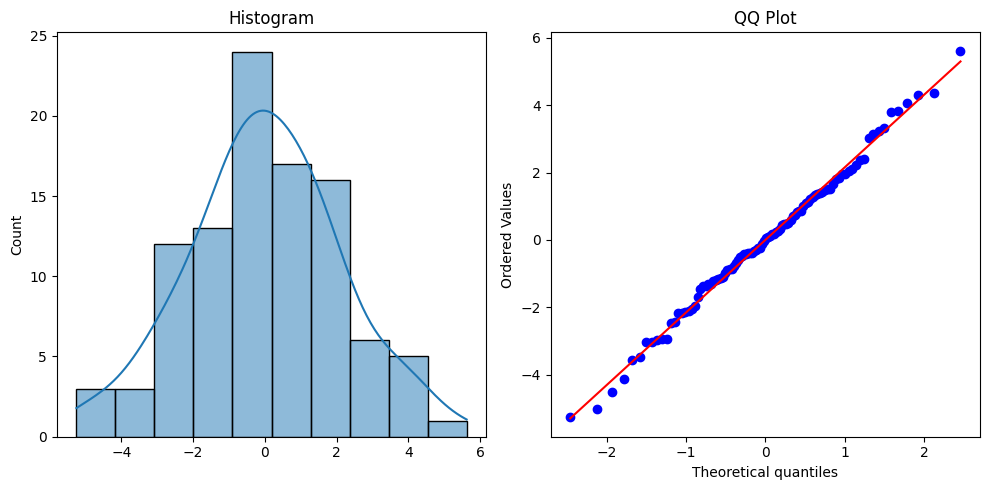

In [15]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Apa kesimpulan Anda berdasarkan plot di atas?**

Berdasarkan histogram residual, pola distribusi residual terlihat mendekati distribusi normal dengan bentuk menyerupai kurva lonceng dan sebagian besar residual terkonsentrasi di sekitar nilai nol. Hal ini menunjukkan bahwa penyebaran residual masih mengikuti pola distribusi normal.

Hal tersebut juga didukung oleh QQ Plot, di mana sebagian besar titik berada di sekitar garis diagonal meskipun terdapat sedikit penyimpangan pada bagian ujung distribusi. Dengan demikian, residual dapat dianggap mendekati distribusi normal, sehingga asumsi normalitas pada model regresi telah terpenuhi.

In [16]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9942433812259159, p-value = 0.9505380764045676


**Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan
Anda berdasarkan plot?**

Ya, hasil uji Shapiro-Wilk konsisten dengan kesimpulan berdasarkan plot. Nilai p-value = 0,9505 > 0,05, sehingga gagal menolak H₀ yang berarti residual dapat dianggap berdistribusi normal.

Hasil ini sesuai dengan histogram dan QQ Plot yang menunjukkan bahwa sebagian besar residual mengikuti pola distribusi normal. Dengan demikian, asumsi normalitas residual pada model regresi telah terpenuhi.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [18]:
# Menentukan parameter simulasi
np.random.seed(1058)
n_periods = 120
beta_0, beta_1, beta_2= 108, 29, 1.16 #nim M0501251058)
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

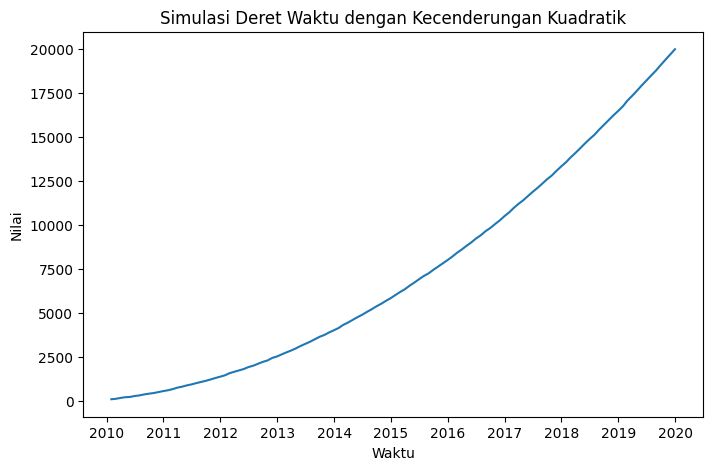

In [19]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

**Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?**

Berdasarkan grafik, deret waktu menunjukkan adanya kecenderungan kuadratik positif, di mana nilai deret meningkat dengan laju pertumbuhan yang semakin besar seiring bertambahnya waktu. Hal ini ditunjukkan oleh bentuk kurva yang semakin melengkung ke atas akibat adanya pengaruh komponen kuadratik $(t^2)$ yang menyebabkan peningkatan nilai menjadi semakin cepat.

Dibandingkan dengan kecenderungan linear, pola kuadratik memiliki perubahan laju pertumbuhan yang tidak konstan. Pada pola linear, peningkatan nilai terjadi secara tetap sehingga membentuk garis lurus, sedangkan pada pola kuadratik peningkatan nilai semakin besar pada setiap periode sehingga menghasilkan pola kurva yang semakin curam. Hal ini menunjukkan bahwa komponen kuadratik memberikan pengaruh terhadap percepatan pertumbuhan deret waktu.

In [21]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.757e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          3.61e-321
Time:                        13:52:16   Log-Likelihood:                -455.80
No. Observations:                 120   AIC:                             917.6
Df Residuals:                     117   BIC:                             926.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        111.5008      2.946     37.852      0.0

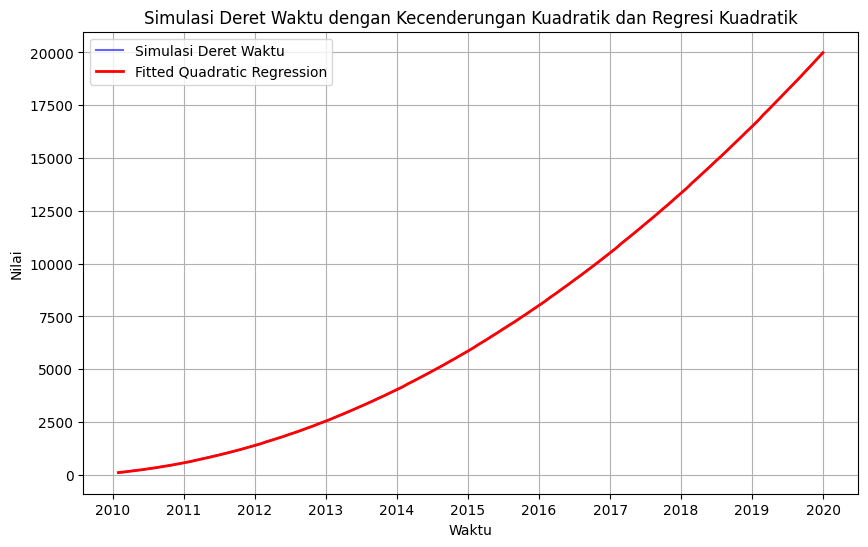

In [23]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

**Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!**

Berdasarkan grafik hasil pemodelan, regresi kuadratik mampu mengikuti pola data dengan baik. Kurva hasil fitting terlihat hampir berimpit dengan deret waktu simulasi, yang menunjukkan bahwa model mampu menangkap pola kecenderungan kuadratik pada data.

Namun, untuk memastikan seluruh asumsi regresi terpenuhi, perlu dilakukan pemeriksaan lebih lanjut terhadap residual, seperti uji normalitas residual, uji heteroskedastisitas, dan uji autokorelasi. Dari grafik ini dapat disimpulkan bahwa bentuk model yang digunakan sudah sesuai dengan pola tren kuadratik pada data.

**Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!**

Model regresi kuadratik yang dipaskan sudah tepat, karena bentuk kurva hasil prediksi mengikuti pola peningkatan data yang semakin cepat dan membentuk kurva ke atas. Hal ini menunjukkan bahwa model kuadratik mampu menjelaskan perubahan nilai deret yang dipengaruhi oleh komponen waktu kuadrat (t²).

Dengan demikian, penggunaan model regresi kuadratik lebih sesuai dibandingkan model linear untuk deret yang memiliki pola pertumbuhan yang tidak konstan dan mengalami percepatan peningkatan dari waktu ke waktu.

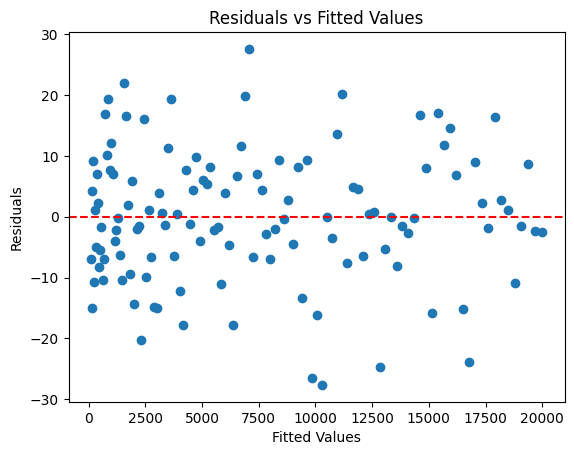

In [24]:
#cek asumsi model regresi kuadratik
# Residual model regresi kuadratik
residuals = model_quad.resid

# 1. Plot residual vs fitted values
import matplotlib.pyplot as plt

fitted = model_quad.fittedvalues

plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


**Interpretasi Plot residual**

Berdasarkan plot, residual terlihat menyebar secara acak di sekitar garis nol tanpa membentuk pola tertentu. Hal ini menunjukkan bahwa model regresi kuadratik sudah mampu menangkap pola kecenderungan data dengan baik dan tidak terdapat pola sistematis pada kesalahan prediksi.

Selain itu, penyebaran residual terlihat cukup merata pada berbagai nilai fitted values, meskipun terdapat beberapa residual dengan nilai yang lebih besar. Kondisi ini menunjukkan tidak adanya indikasi kuat heteroskedastisitas, sehingga asumsi bahwa varians error relatif konstan dapat dianggap terpenuhi. Dengan demikian, model regresi kuadratik cukup sesuai untuk menjelaskan pola perubahan data.

In [25]:
#Uji Heteroskedastisitas (Breusch-Pagan)

from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, model_quad.model.exog)

print("P-value Breusch-Pagan:", bp_test[1])

P-value Breusch-Pagan: 0.49485699302437003


**interpretasi uji heteroskedastisitas**

Hasil uji Breusch-Pagan menunjukkan nilai p-value = 0,4949. Karena nilai tersebut lebih besar dari tingkat signifikansi α = 0,05, maka gagal menolak H₀.

Artinya, tidak terdapat indikasi heteroskedastisitas pada residual model regresi kuadratik. Varians residual dapat dianggap konstan (homoskedastis), sehingga asumsi terkait kesamaan varians error pada model regresi telah terpenuhi.

In [29]:
#Uji Autokorelasi Residual (Ljung-Box)
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(residuals, lags=20, return_df=True)

print(ljung_box)

      lb_stat  lb_pvalue
1    2.616386   0.105765
2    3.058533   0.216695
3    3.062576   0.382077
4    7.455934   0.113668
5   10.421545   0.064135
6   10.897671   0.091591
7   14.780539   0.038918
8   14.896263   0.061194
9   19.559167   0.020837
10  19.779349   0.031410
11  21.742916   0.026442
12  22.260761   0.034699
13  22.506150   0.047999
14  22.807858   0.063469
15  22.901419   0.086255
16  29.317815   0.021879
17  30.026249   0.026156
18  30.117678   0.036318
19  31.086326   0.039501
20  32.828324   0.035233


**interpretasi uji autokorelasi**

Berdasarkan hasil uji Ljung-Box, beberapa nilai p-value berada di bawah 0,05, terutama pada lag ke-7, lag ke-9 hingga ke-13, serta lag ke-16 hingga ke-20. Hal ini menunjukkan bahwa pada beberapa lag terdapat bukti untuk menolak H₀, sehingga residual masih memiliki indikasi adanya autokorelasi.

Dengan demikian, residual model regresi kuadratik belum sepenuhnya bersifat acak (independen) karena masih terdapat pola ketergantungan antar waktu pada beberapa periode. Artinya, meskipun model sudah mampu menangkap pola kecenderungan kuadratik utama pada data, masih terdapat sebagian informasi temporal yang belum dapat dijelaskan oleh model.

In [30]:
#Uji Normalitas Residual (Shapiro-Wilk)
from scipy import stats

shapiro_test = stats.shapiro(residuals)

print("Statistic:", shapiro_test.statistic)
print("P-value:", shapiro_test.pvalue)

Statistic: 0.99319720515256
P-value: 0.828760203564116


**interpretasi uji normalitas**

Hasil uji Shapiro-Wilk menunjukkan nilai statistic = 0,9932 dengan p-value = 0,8288. Karena nilai p-value > 0,05, maka gagal menolak H₀.

Artinya, residual model regresi kuadratik dapat dianggap berdistribusi normal. Dengan demikian, asumsi normalitas residual pada model regresi telah terpenuhi.

**Interpretasi Asumsi Model Regresi Kuadratik:**

Berdasarkan hasil pengujian asumsi model regresi kuadratik, model telah memenuhi sebagian besar asumsi regresi. Hasil uji normalitas menggunakan Shapiro-Wilk menunjukkan bahwa residual berdistribusi normal dengan nilai p-value = 0,8288 > 0,05. Selain itu, hasil uji Breusch-Pagan menunjukkan nilai p-value = 0,4949 > 0,05, sehingga tidak terdapat indikasi heteroskedastisitas dan varians residual dapat dianggap konstan.

Namun, berdasarkan hasil uji Ljung-Box, terdapat beberapa lag dengan nilai p-value < 0,05 yang menunjukkan adanya indikasi autokorelasi pada residual. Hal ini berarti residual belum sepenuhnya bersifat acak karena masih terdapat pola ketergantungan antar waktu pada beberapa periode.

Secara keseluruhan, model regresi kuadratik sudah mampu menggambarkan pola utama data dengan baik, terutama dalam menangkap kecenderungan pertumbuhan yang bersifat kuadratik. Meskipun demikian, keberadaan autokorelasi menunjukkan bahwa masih terdapat informasi temporal yang belum sepenuhnya dijelaskan oleh model, sehingga pengembangan model dengan mempertimbangkan komponen waktu tambahan dapat dilakukan untuk memperoleh hasil yang lebih optimal.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [34]:
# Menentukan parameter simulasi
np.random.seed(1058)
n_periods = 120
beta0, beta1, beta2=108,-1450, -116
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


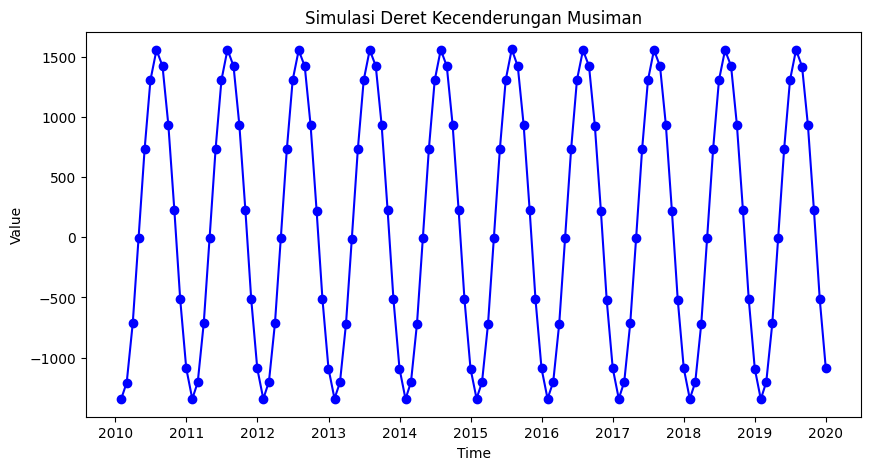

In [35]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


**Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?**


Berdasarkan grafik, deret waktu menunjukkan pola musiman dengan periode 12 bulan. Hal ini terlihat dari pola naik-turun yang berulang secara konsisten setiap 12 pengamatan. Nilai deret mengalami peningkatan hingga mencapai puncak, kemudian mengalami penurunan hingga titik terendah, dan pola tersebut kembali berulang pada periode berikutnya.

Deret ini tidak menunjukkan adanya kecenderungan tren naik atau turun dalam jangka panjang, sehingga perubahan nilai utama dipengaruhi oleh komponen musiman. Pola fluktuasi terlihat stabil dari tahun ke tahun dengan amplitudo yang relatif sama, sedangkan variasi kecil pada setiap periode disebabkan oleh adanya noise acak. Dengan demikian, deret waktu tersebut dapat dikategorikan sebagai deret musiman dengan pola tahunan yang kuat.

In [36]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [38]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [39]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [40]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.652e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          7.43e-288
Time:                        14:06:03   Log-Likelihood:                -252.25
No. Observations:                 120   AIC:                             528.5
Df Residuals:                     108   BIC:                             561.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari    -1343.3356      0.660  -2035.311      0.0

**Bagaimana interpretasi dari hasil tersebut?**

Hasil regresi menunjukkan bahwa model mampu menjelaskan pola musiman dengan sangat baik, ditunjukkan oleh nilai R-squared = 1,000. Artinya, hampir seluruh variasi nilai deret waktu dapat dijelaskan oleh faktor musiman bulanan, sedangkan variasi kecil yang tersisa dipengaruhi oleh komponen lain seperti noise.

Seluruh koefisien bulan memiliki nilai p-value < 0,05, sehingga setiap bulan memberikan pengaruh yang signifikan terhadap pola deret waktu. Perbedaan nilai koefisien antar bulan menunjukkan adanya variasi musiman yang kuat sepanjang tahun, dengan nilai tertinggi terjadi pada bulan Juli (1558,01) dan nilai terendah terjadi pada bulan Januari (-1343,34).

Nilai Durbin-Watson = 1,791 menunjukkan bahwa residual relatif tidak mengalami autokorelasi yang kuat. Selain itu, hasil uji normalitas residual menggunakan Jarque-Bera menunjukkan nilai p-value = 0,557 > 0,05, sehingga residual dapat dianggap berdistribusi normal.

Secara keseluruhan, model regresi musiman sudah sesuai dan mampu menggambarkan pola musiman dengan periode 12 bulan secara sangat baik. Model berhasil menangkap pola naik-turun tahunan tanpa adanya pengaruh tren jangka panjang yang dominan.

In [41]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

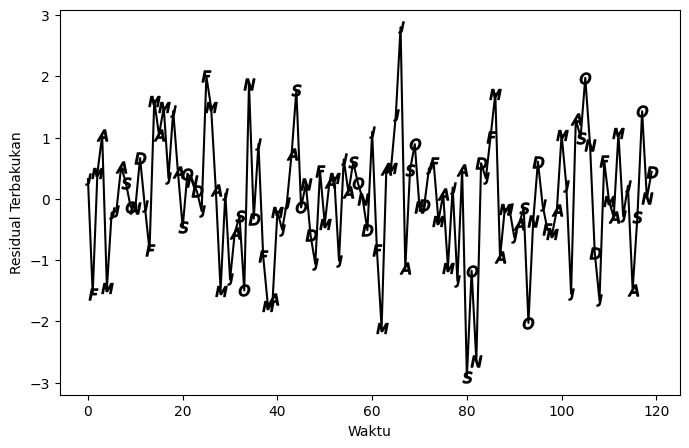

In [42]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


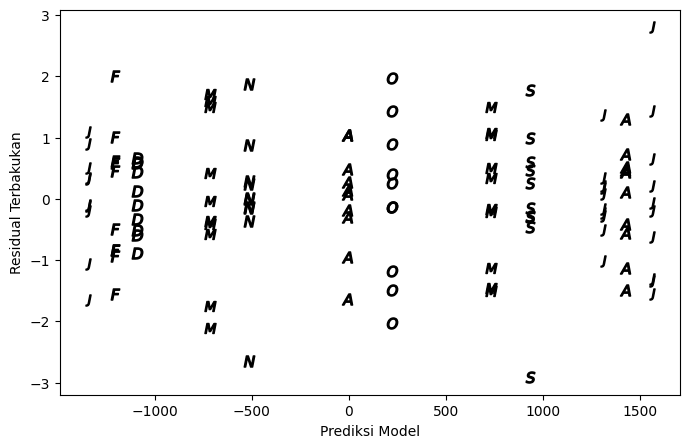

In [43]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

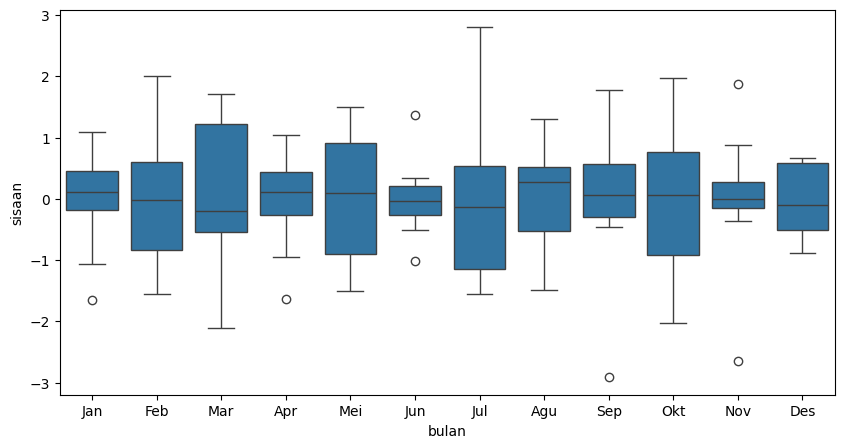

In [44]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

**Bagaimana interpretasi Anda terhadap tiga plot di atas?**
1. Plot residual terhadap waktu (Residual Terbukakan vs Waktu)
Plot menunjukkan bahwa residual berfluktuasi di sekitar nilai nol tanpa membentuk pola tren tertentu. Hal ini menunjukkan bahwa model sudah mampu menangkap pola musiman utama pada data, sehingga kesalahan prediksi cenderung bersifat acak. Namun, masih terdapat beberapa residual dengan nilai yang cukup besar, yang menunjukkan adanya variasi kecil yang belum sepenuhnya dijelaskan oleh model.
2. Plot residual terhadap nilai prediksi model (Residual vs Prediksi Model)
Residual terlihat tersebar secara acak pada berbagai nilai prediksi model dan tidak menunjukkan pola tertentu. Hal ini menunjukkan bahwa besar kecilnya nilai prediksi tidak memengaruhi besarnya kesalahan model secara sistematis. Dengan demikian, tidak terdapat indikasi kuat adanya masalah heteroskedastisitas dan asumsi kestabilan varians residual dapat dianggap terpenuhi.
3. Boxplot residual berdasarkan bulan
Boxplot menunjukkan bahwa penyebaran residual pada setiap bulan relatif berada di sekitar nilai nol, meskipun terdapat beberapa pencilan (outlier) pada beberapa bulan. Variasi residual antar bulan terlihat cukup stabil, sehingga tidak menunjukkan adanya perbedaan pola kesalahan yang signifikan antar periode musiman.

**Kesimpulan umum:**

Berdasarkan ketiga plot tersebut, model regresi musiman sudah cukup baik dalam menangkap pola musiman data. Residual cenderung menyebar secara acak dan tidak menunjukkan pola sistematis, meskipun masih terdapat beberapa pencilan yang menunjukkan adanya variasi tertentu yang belum dapat dijelaskan oleh model.

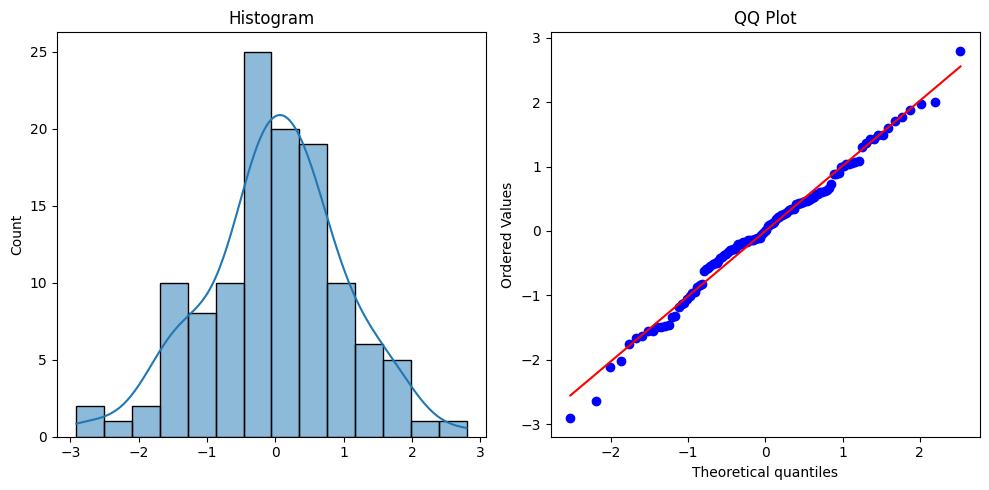

In [45]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?**

Berdasarkan histogram residual, distribusi residual terlihat mendekati bentuk normal dan terpusat di sekitar nilai nol. Hal ini diperkuat oleh QQ Plot, di mana sebagian besar titik mengikuti garis diagonal, meskipun terdapat sedikit penyimpangan pada bagian ekor distribusi.

Dengan demikian, model regresi musiman yang dipaskan dapat dikatakan cukup tepat karena residual telah menunjukkan pola distribusi yang mendekati normal. Namun, untuk memastikan seluruh asumsi model terpenuhi, tetap diperlukan pengujian statistik tambahan seperti uji normalitas, heteroskedastisitas, dan autokorelasi residual.

**Hitunglah statistik uji untuk mengecek asumsi model**

Berdasarkan hasil evaluasi residual, model regresi musiman telah menunjukkan kesesuaian yang baik dalam menggambarkan pola data. Residual cenderung memenuhi asumsi normalitas dan memiliki penyebaran yang relatif stabil. Namun, pemeriksaan statistik terhadap autokorelasi dan varians residual tetap diperlukan untuk memastikan bahwa model benar-benar memenuhi seluruh asumsi regresi.

Dengan demikian, model regresi musiman dapat digunakan untuk menjelaskan pola musiman periode 12 bulan, dengan catatan validasi residual tetap dilakukan melalui pengujian statistik.

In [47]:
# Hitung statistik uji untuk mengecek asumsi model tanpa intersep

import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
import statsmodels.api as sm


# Residual dari model tanpa intersep
residuals = musiman.resid


# 1. Uji Normalitas Residual (Shapiro-Wilk)

shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("=== Shapiro-Wilk Test ===")
print("Statistic :", shapiro_stat)
print("P-value   :", shapiro_p)


# 2. Uji Heteroskedastisitas (Breusch-Pagan)

# Tambahkan konstanta hanya untuk kebutuhan uji BP
exog_bp = sm.add_constant(musiman.model.exog)

bp_test = het_breuschpagan(
    residuals,
    exog_bp
)

print("\n=== Breusch-Pagan Test ===")
print("LM Statistic :", bp_test[0])
print("P-value      :", bp_test[1])


# 3. Uji Autokorelasi (Ljung-Box)

ljung_test = acorr_ljungbox(
    residuals,
    lags=[12],
    return_df=True
)

print("\n=== Ljung-Box Test ===")
print(ljung_test)

=== Shapiro-Wilk Test ===
Statistic : 0.9899876473937875
P-value   : 0.533229530459341

=== Breusch-Pagan Test ===
LM Statistic : 10.914271310046132
P-value      : 0.5362796234854625

=== Ljung-Box Test ===
      lb_stat  lb_pvalue
12  11.290376   0.504211


**Kesimpulan Uji Asumsi Model Regresi Musiman Tanpa Intersep:**

Berdasarkan hasil pengujian asumsi model, diperoleh:

Uji Normalitas Residual (Shapiro-Wilk)
1. Uji Normalitas Residual (Shapiro-Wilk)
Hasil uji menunjukkan nilai p-value = 0,5332 > 0,05, sehingga gagal menolak H₀. Artinya, residual model dapat dianggap berdistribusi normal dan memenuhi asumsi normalitas residual.
2. Uji Heteroskedastisitas (Breusch-Pagan)
Hasil uji menunjukkan nilai p-value = 0,5363 > 0,05, sehingga gagal menolak H₀. Artinya, tidak terdapat indikasi heteroskedastisitas pada residual model dan varians residual dapat dianggap konstan (homoskedastis).
3. Uji Autokorelasi (Ljung-Box)
Hasil uji menunjukkan nilai p-value = 0,5042 > 0,05, sehingga gagal menolak H₀. Artinya, tidak terdapat indikasi autokorelasi pada residual dan residual dapat dianggap bersifat independen.

**Kesimpulan umum:**

Model regresi musiman tanpa intersep telah memenuhi asumsi utama regresi, yaitu residual berdistribusi normal, memiliki varians yang konstan, dan tidak mengalami autokorelasi. Dengan demikian, model yang dipaskan sudah cukup baik dalam menggambarkan pola musiman pada deret waktu.

In [48]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [49]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.652e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          7.43e-288
Time:                        14:36:39   Log-Likelihood:                -252.25
No. Observations:                 120   AIC:                             528.5
Df Residuals:                     108   BIC:                             561.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1343.3356      0.660  -2035.311      0.0

**Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!**

$$
Y_t=\beta_0+\beta_1X_1+\beta_2X_2+...+\beta_{12}X_{12}+e_t
$$

dengan nilai intersep (β₀) = -1343,3356 sebagai nilai dasar deret pada bulan Januari. Koefisien bulan menunjukkan perubahan nilai dibandingkan bulan Januari sebagai kategori acuan. Contohnya, koefisien Februari = 138,3539 berarti nilai bulan Februari lebih tinggi sebesar 138,35 dibandingkan Januari, sedangkan koefisien Juli = 2901,3489 menunjukkan bahwa nilai Juli lebih tinggi sebesar 2901,35 dibandingkan bulan Januari.

Pada model tanpa intersep, persamaan menjadi:

$$
Y_t=\beta_1X_1+\beta_2X_2+...+\beta_{12}X_{12}+e_t
$$

sehingga setiap koefisien bulan langsung menggambarkan nilai rata-rata atau pengaruh masing-masing bulan tanpa dibandingkan dengan kategori dasar tertentu.



**Apakah model dengan intersep sudah memenuhi asumsi regresi?**

Ya, model dengan intersep sudah cukup memenuhi asumsi regresi. Hal ini terlihat dari nilai R-squared = 1,000 yang menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi data. Selain itu, residual berdistribusi normal berdasarkan uji Jarque-Bera (p-value = 0,557 > 0,05) dan nilai Durbin-Watson = 1,791 menunjukkan bahwa tidak terdapat indikasi autokorelasi yang kuat pada residual.

Sehingga, model dengan intersep dapat dikatakan sudah baik untuk menggambarkan pola musiman pada data karena mampu menangkap perbedaan pola nilai antar bulan secara signifikan.



In [50]:
# Uji asumsi model dengan intersep

import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox


# Mengambil residual model dengan intersep
residuals_int = musiman_int.resid


# 1. Uji Normalitas Residual (Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(residuals_int)

print("=== Shapiro-Wilk Test ===")
print("Statistic :", shapiro_stat)
print("P-value   :", shapiro_p)


# 2. Uji Heteroskedastisitas (Breusch-Pagan)
bp_test = het_breuschpagan(
    residuals_int,
    musiman_int.model.exog
)

print("\n=== Breusch-Pagan Test ===")
print("LM Statistic :", bp_test[0])
print("P-value      :", bp_test[1])


# 3. Uji Autokorelasi (Ljung-Box)
ljung_test = acorr_ljungbox(
    residuals_int,
    lags=[12],
    return_df=True
)

print("\n=== Ljung-Box Test ===")
print(ljung_test)

=== Shapiro-Wilk Test ===
Statistic : 0.9899876473937906
P-value   : 0.5332295304596186

=== Breusch-Pagan Test ===
LM Statistic : 10.914271310050182
P-value      : 0.4504731149457868

=== Ljung-Box Test ===
      lb_stat  lb_pvalue
12  11.290376   0.504211


Berdasarkan hasil pengujian asumsi model dengan intersep diperoleh:

1. Uji Normalitas Residual (Shapiro-Wilk)
Hasil uji menunjukkan nilai p-value = 0,5332 > 0,05, sehingga gagal menolak H₀. Artinya, residual model dapat dianggap berdistribusi normal dan asumsi normalitas residual telah terpenuhi.

2. Uji Heteroskedastisitas (Breusch-Pagan)
Hasil uji menunjukkan nilai p-value = 0,4505 > 0,05, sehingga gagal menolak H₀. Artinya, tidak terdapat indikasi heteroskedastisitas pada residual model dan varians residual dapat dianggap konstan (*homoskedastis*).

3. Uji Autokorelasi (Ljung-Box)
Hasil uji menunjukkan nilai p-value = 0,5042 > 0,05, sehingga gagal menolak H₀. Artinya, tidak terdapat indikasi autokorelasi pada residual dan residual dapat dianggap bersifat independen antar waktu.

**Kesimpulan umum:**


Model regresi musiman dengan intersep telah memenuhi asumsi utama regresi, yaitu residual berdistribusi normal, memiliki varians residual yang konstan, dan tidak mengalami autokorelasi. Dengan demikian, model yang dipaskan sudah cukup baik dalam menjelaskan pola musiman pada data.

**Bedanya ?**

Kedua model sebenarnya dapat digunakan untuk menggambarkan pola musiman. Model tanpa intersep lebih mudah untuk membaca nilai setiap bulan secara langsung, sedangkan model dengan intersep lebih baik untuk menjelaskan bagaimana setiap bulan berbeda dibandingkan bulan referensi. Pada analisis regresi musiman, model dengan intersep biasanya lebih sering digunakan karena interpretasi koefisiennya lebih informatif.

## Kecenderungan Linear dan Musiman

In [51]:
# Parameter
np.random.seed(1058)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 29, 580 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


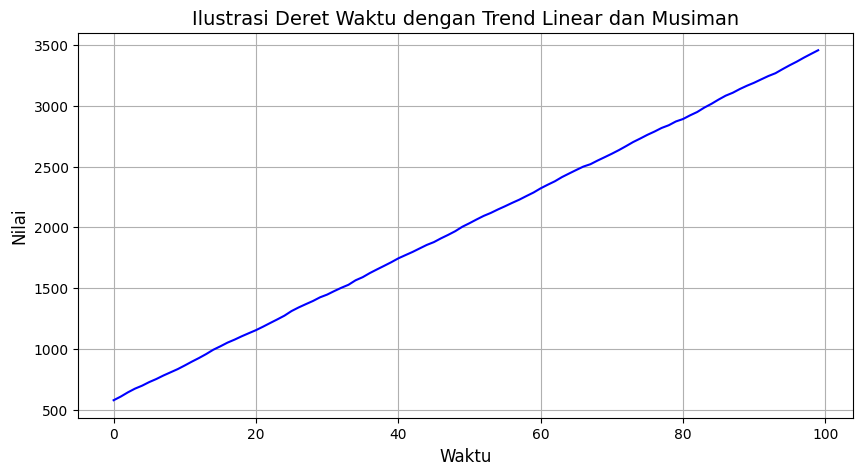

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

**Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.**

Berdasarkan pola deret waktu yang terbentuk, data menunjukkan adanya kecenderungan tren linear positif dan pola musiman yang berulang setiap 12 periode. Oleh karena itu, model yang digunakan adalah regresi linear dengan variabel musiman, yaitu model yang menggabungkan komponen tren dan komponen musiman.

Bentuk umum model:

$$
Y_t = \beta_0 + \beta_1 t + \beta_2 X_1 + \beta_3 X_2 + ... + \beta_k X_k + e_t
$$

Keterangan:
- β₀ = intersep atau nilai dasar dari deret waktu.
- β₁t = komponen tren linear yang menunjukkan perubahan nilai berdasarkan waktu.
- X₁, X₂, ..., Xₖ = variabel dummy musiman yang digunakan untuk menangkap pola musiman.
- eₜ = error atau noise acak dalam data.

Model ini dipilih karena mampu menangkap dua karakteristik utama deret waktu, yaitu peningkatan nilai dalam jangka panjang akibat komponen tren linear dan variasi berulang akibat komponen musiman.

Dengan demikian, regresi linear dengan variabel musiman dapat digunakan untuk memodelkan deret waktu yang memiliki kombinasi antara pola pertumbuhan dan pola berulang secara periodik.

In [54]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [55]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [56]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.372e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          5.05e-224
Time:                        14:48:20   Log-Likelihood:                -207.29
No. Observations:                 100   AIC:                             440.6
Df Residuals:                      87   BIC:                             474.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      579.5196      0.768    754.184      0.0

**Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?**

Model regresi yang terbentuk:

$$
Y_t=\beta_{bulan}+\beta_1(period)+e_t
$$

Berdasarkan hasil regresi, nilai koefisien period = 28,9898 menunjukkan bahwa setiap kenaikan 1 periode waktu akan meningkatkan nilai deret sebesar 28,9898 unit. Hal ini menunjukkan adanya tren linear positif pada data.

Koefisien pada variabel bulan menunjukkan pola musiman. Nilai koefisien masing-masing bulan menggambarkan nilai deret pada periode tersebut. Contohnya:

- Bulan April memiliki nilai koefisien sebesar 586,0061, menunjukkan nilai relatif paling tinggi dibandingkan bulan lainnya.
- Bulan Oktober memiliki nilai koefisien sebesar 573,8162, menunjukkan nilai relatif lebih rendah dibandingkan periode lainnya.

Secara keseluruhan, koefisien bulan menunjukkan adanya variasi musiman, sedangkan koefisien periode menunjukkan adanya peningkatan nilai akibat komponen tren waktu. Model ini mampu menangkap kombinasi antara tren linear dan pola musiman pada deret waktu.





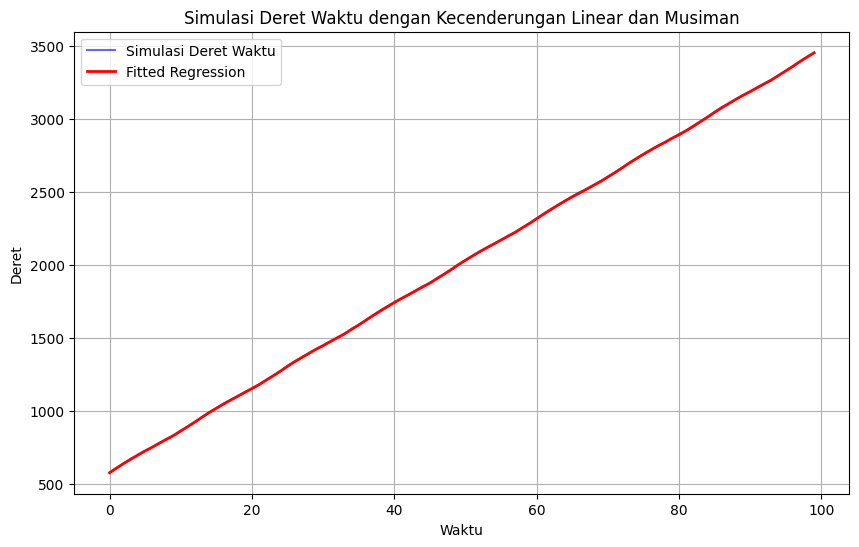

In [57]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Berdasarkan grafik hasil pengepasan model, garis regresi (fitted regression) berwarna merah hampir berimpit dengan pola data simulasi berwarna biru. Hal ini menunjukkan bahwa model regresi linear dengan variabel musiman mampu menangkap komponen tren linear dan pola musiman pada deret waktu dengan baik.

Model berhasil menggambarkan peningkatan nilai secara bertahap akibat komponen tren waktu, serta mempertahankan variasi pola musiman yang terdapat dalam data. Jika hasil pengujian residual menunjukkan nilai p-value > 0,05 pada seluruh pengujian asumsi, maka dapat disimpulkan bahwa tidak terdapat pelanggaran asumsi regresi.

Dengan demikian, model regresi linear dengan variabel musiman sudah sesuai untuk menggambarkan pola deret waktu yang memiliki kombinasi antara kecenderungan peningkatan jangka panjang dan variasi musiman secara periodik.

**Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!**

In [59]:
# Uji asumsi model

import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
import statsmodels.api as sm

# Mengambil residual model
residuals = model.resid


# 1. Uji Normalitas Residual (Shapiro-Wilk)

shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("=== Shapiro-Wilk Test ===")
print("Statistic :", shapiro_stat)
print("P-value   :", shapiro_p)


# 2. Uji Heteroskedastisitas (Breusch-Pagan)

bp_test = het_breuschpagan(
    residuals,
    model.model.exog
)

print("\n=== Breusch-Pagan Test ===")
print("LM Statistic :", bp_test[0])
print("P-value      :", bp_test[1])


# 3. Uji Autokorelasi (Ljung-Box)

ljung_test = acorr_ljungbox(
    residuals,
    lags=[12],
    return_df=True
)

print("\n=== Ljung-Box Test ===")
print(ljung_test)

=== Shapiro-Wilk Test ===
Statistic : 0.9942433812259159
P-value   : 0.9505380764045676

=== Breusch-Pagan Test ===
LM Statistic : 0.3700373145370639
P-value      : 0.542983929223465

=== Ljung-Box Test ===
      lb_stat  lb_pvalue
12  23.626439   0.022855


**Kesimpulan Uji Asumsi Model Regresi Linear dengan Variabel Musiman:**

1. Uji Normalitas Residual (Shapiro-Wilk)
Hasil uji menunjukkan nilai p-value = 0,9505 > 0,05, sehingga gagal menolak H₀. Artinya, residual model dapat dianggap berdistribusi normal dan asumsi normalitas residual telah terpenuhi.

2. Uji Heteroskedastisitas (Breusch-Pagan)
Hasil uji menunjukkan nilai p-value = 0,5430 > 0,05, sehingga gagal menolak H₀. Artinya, tidak terdapat indikasi heteroskedastisitas pada residual dan varians residual dapat dianggap konstan (*homoskedastis*).

3. Uji Autokorelasi (Ljung-Box)
Hasil uji menunjukkan nilai p-value = 0,0229 < 0,05, sehingga menolak H₀. Artinya, terdapat indikasi adanya autokorelasi pada residual, sehingga residual belum sepenuhnya bersifat acak (*independen*) antar waktu.

**KESIMPULAN:**

Model regresi linear dengan variabel musiman telah memenuhi asumsi normalitas dan homoskedastisitas, tetapi masih terdapat pelanggaran pada asumsi autokorelasi. Hal ini menunjukkan bahwa residual masih memiliki hubungan antar waktu yang belum sepenuhnya dijelaskan oleh model.

Dengan demikian, model sudah mampu menangkap pola tren linear dan musiman pada data, namun masih diperlukan pengembangan model lebih lanjut dengan mempertimbangkan komponen autokorelasi agar pola ketergantungan waktu dapat dijelaskan dengan lebih baik.

**Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.**

### Dekomposisi Deret Waktu

Dalam analisis deret waktu, terkadang pola data tidak dapat diketahui hanya melalui visualisasi grafik. Oleh karena itu, diperlukan metodedekomposisi deret waktu untuk mengidentifikasi komponen-komponen yang terdapat dalam data.

Dekomposisi deret waktu bertujuan untuk memisahkan deret menjadi tiga komponen utama, yaitu:

1. Komponen Tren (Trend)  
   Menunjukkan pola pergerakan jangka panjang dalam data, seperti peningkatan atau penurunan nilai secara bertahap.

2. Komponen Musiman (Seasonality)
   Menunjukkan pola berulang dalam periode tertentu, misalnya pola bulanan, kuartalan, atau tahunan.

3. Komponen Noise/Residual
   Merupakan variasi acak dalam data yang tidak dapat dijelaskan oleh tren maupun pola musiman.

Secara umum, dekomposisi deret waktu dapat dituliskan sebagai:

$$
Y_t = T_t + S_t + N_t
$$

dengan:
- $Y_t$ = nilai deret waktu pada periode ke-$t$
- $T_t$ = komponen tren
- $S_t$ = komponen musiman
- $N_t$ = komponen noise

Melalui dekomposisi, dapat diketahui apakah suatu deret memiliki tren, pola musiman, atau hanya dipengaruhi oleh variasi acak.

In [60]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

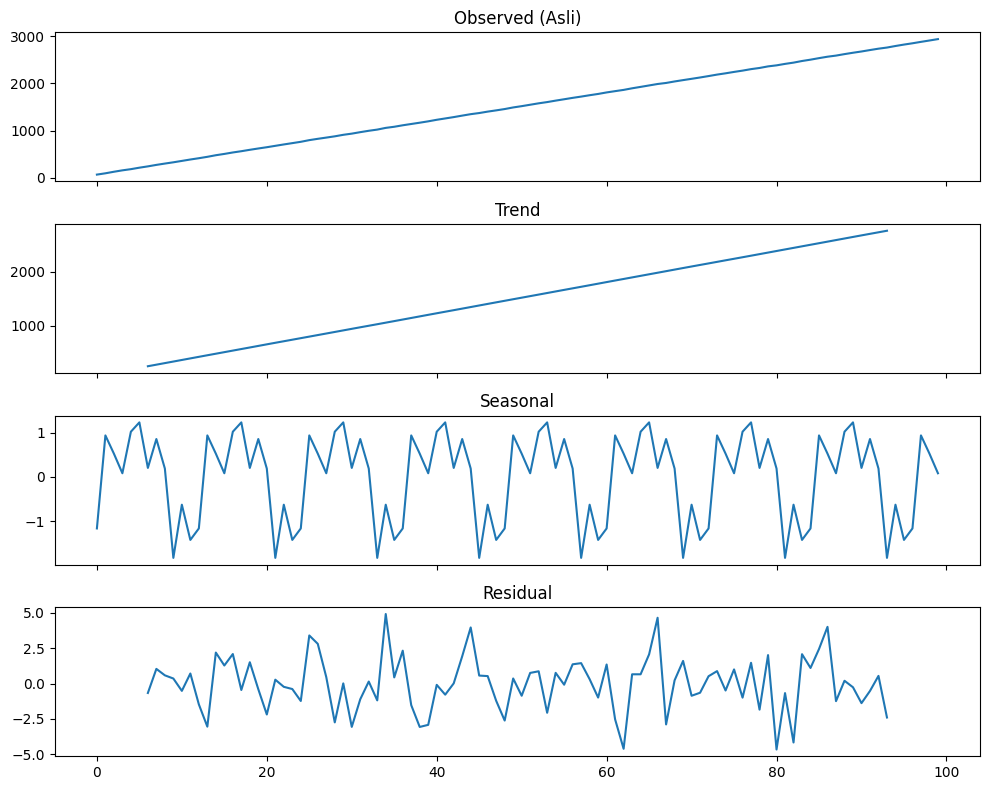

In [61]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

Berdasarkan hasil dekomposisi, deret waktu terdiri dari tiga komponen utama, yaitu tren, musiman, dan residual.
1. Komponen Tren (Trend)
menunjukkan pola peningkatan linear yang kuat dari waktu ke waktu. Hal ini terlihat dari grafik tren yang terus meningkat secara konsisten, sehingga menunjukkan bahwa nilai deret mengalami pertumbuhan jangka panjang yang dipengaruhi oleh komponen waktu.konsisten dalam jangka panjang.
2. Komponen Musiman (Seasonal)
menunjukkan adanya pola berulang secara periodik. Fluktuasi naik dan turun terjadi secara konsisten pada interval tertentu, yang menunjukkan adanya pengaruh musiman dalam data. Pola musiman terlihat stabil dengan amplitudo yang relatif sama pada setiap periode.
3. Komponen Residual (Noise)
menunjukkan variasi acak yang tersisa setelah pengaruh tren dan musiman dihilangkan. Residual berfluktuasi di sekitar nilai nol tanpa membentuk pola tertentu, sehingga menunjukkan bahwa sebagian besar pola utama dalam data telah berhasil dijelaskan oleh komponen tren dan musiman.

**KESIMPULAN:**

Hasil dekomposisi menunjukkan bahwa deret waktu memiliki komponen tren meningkat yang dominan dan pola musiman yang berulang secara konsisten, sedangkan komponen residual relatif kecil dan bersifat acak. Dengan demikian, model yang mempertimbangkan komponen tren dan musiman sudah sesuai untuk menggambarkan karakteristik utama dari data deret waktu tersebut.

In [62]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

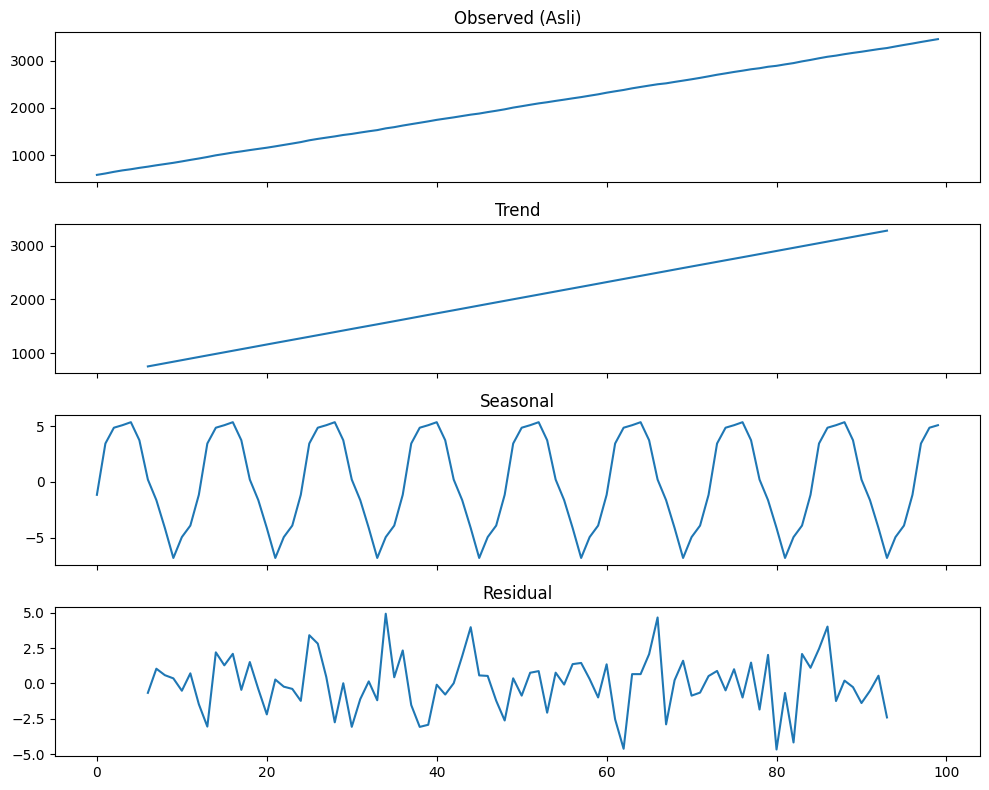

In [63]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

Berdasarkan hasil dekomposisi, deret waktu terdiri dari tiga komponen utama yaitu tren, musiman, dan residual.
1. Komponen Tren (Trend)
menunjukkan adanya peningkatan linear yang kuat dari waktu ke waktu. Hal ini terlihat dari pola tren yang terus meningkat secara konsisten, sehingga menunjukkan bahwa nilai deret mengalami kenaikan dalam jangka panjang.
2. Komponen Musiman (Seasonal)
menunjukkan pola berulang secara periodik dengan periode tertentu. Pola naik dan turun terlihat stabil pada setiap siklus, dengan amplitudo yang relatif tetap sepanjang waktu. Hal ini menunjukkan adanya pengaruh musiman yang konsisten pada data.
3. Komponen Residual (Noise)
menunjukkan variasi acak yang tersisa setelah komponen tren dan musiman dihilangkan. Residual berfluktuasi di sekitar nilai nol tanpa menunjukkan pola tertentu, sehingga menunjukkan bahwa sebagian besar pola utama data telah berhasil dijelaskan oleh komponen tren dan musiman.

Berdasarkan pola data, model dekomposisi yang sesuai adalah model aditif, karena amplitudo komponen musiman terlihat relatif konstan sepanjang waktu dan tidak mengalami perubahan meskipun nilai tren semakin meningkat.

Secara umum, deret waktu memiliki tren meningkat yang dominan, pola musiman yang stabil, dan residual dengan variasi acak yang relatif kecil. Oleh karena itu, model dekomposisi aditif lebih tepat digunakan untuk menggambarkan struktur data tersebut.

**Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.**

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [65]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1058)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 2.9, 580 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

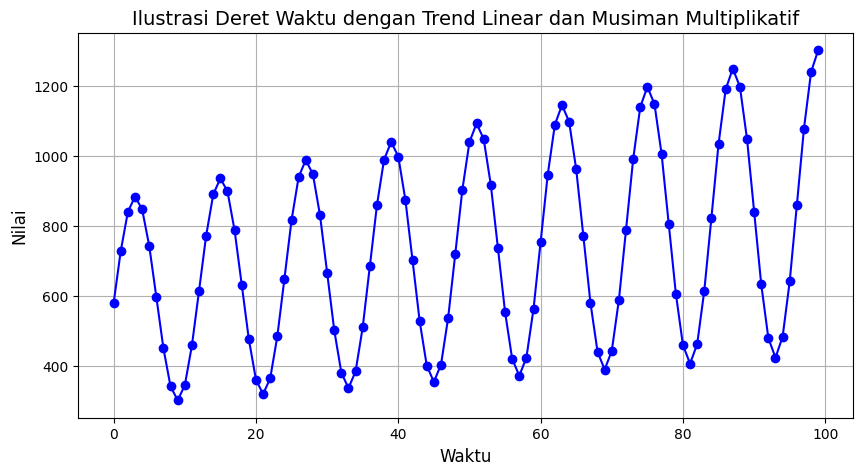

In [66]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

**Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.**

Dekomposisi dengan model multiplikatif hanya dapat dilakukan untuk deret waktu dengan nilai lebih besar dari 0. Jika deret memiliki nilai 0 atau negatif, maka perlu dilakukan transformasi terlebih dahulu agar seluruh nilai menjadi positif.

Berdasarkan grafik, deret waktu menunjukkan adanya tren meningkat yang disertai dengan pola musiman yang berulang. Nilai deret mengalami kenaikan secara bertahap dari waktu ke waktu, sementara pola naik dan turun tetap terjadi pada setiap periode.

Pada model multiplikatif, deret waktu dapat dituliskan sebagai:

$$
Y_t = T_t \times S_t \times N_t
$$

dengan:

- Yt = nilai deret waktu pada periode ke-t
- Tt = komponen tren
- St = komponen musiman
- Nt = komponen noise atau residual

Model multiplikatif digunakan karena besar variasi musiman berubah mengikuti peningkatan tren. Artinya, amplitudo pola musiman tidak bersifat konstan, tetapi meningkat secara proporsional terhadap nilai deret waktu.

Berdasarkan grafik, nilai deret seluruhnya berada di atas 0, sehingga dekomposisi multiplikatif dapat diterapkan tanpa melakukan transformasi data terlebih dahulu.

Secara umum, model multiplikatif sesuai digunakan untuk menggambarkan deret waktu yang memiliki tren meningkat dengan pola musiman yang amplitudonya mengikuti perubahan level data.

In [67]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

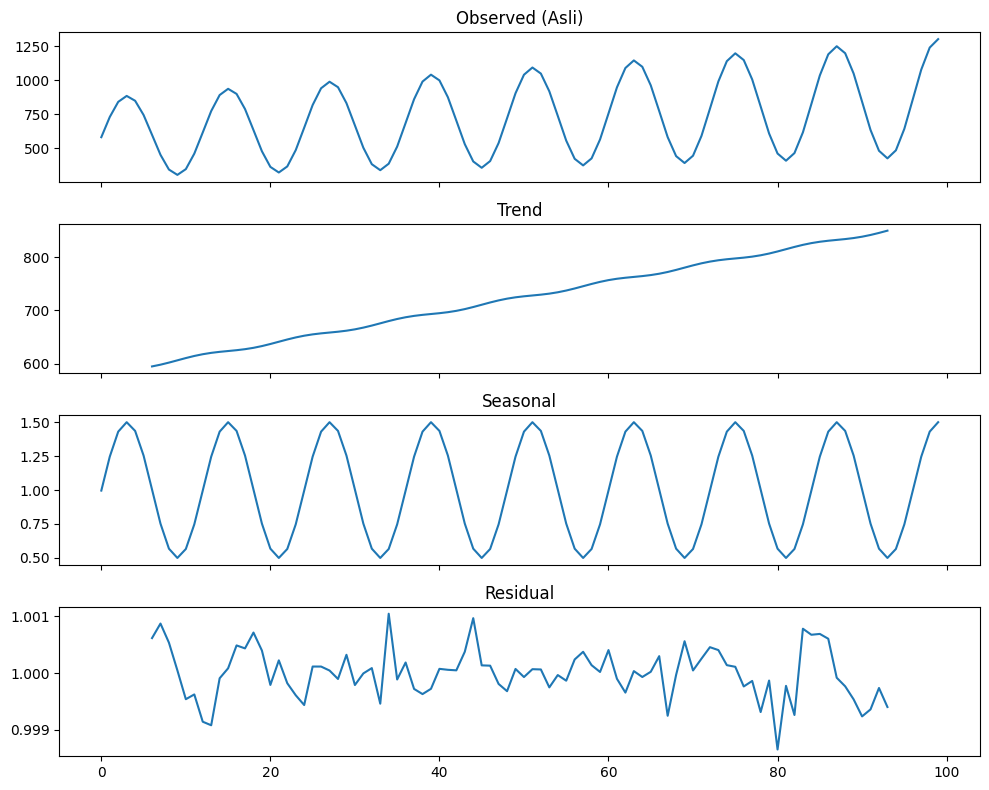

In [68]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?**

Berdasarkan hasil dekomposisi, deret waktu terdiri dari tiga komponen utama yaitu tren, musiman, dan residual.
1. Komponen Tren (Trend)
menunjukkan adanya peningkatan secara bertahap dari waktu ke waktu. Hal ini terlihat dari pola tren yang terus naik, sehingga menunjukkan bahwa nilai deret mengalami pertumbuhan jangka panjang.
2. Komponen Musiman (Seasonal)
menunjukkan pola berulang secara periodik dengan bentuk yang relatif stabil. Pola naik dan turun terjadi secara konsisten pada setiap siklus, namun pengaruhnya mengikuti perubahan level tren. Hal ini menunjukkan adanya komponen musiman yang bersifat proporsional terhadap nilai deret.
3. Komponen Residual (Noise)
menunjukkan variasi acak yang tersisa setelah komponen tren dan musiman dipisahkan. Nilai residual berada di sekitar angka 1 dan tidak menunjukkan pola tertentu, sehingga menunjukkan bahwa sebagian besar pola utama data telah berhasil dijelaskan oleh komponen tren dan musiman.

Berdasarkan karakteristik tersebut, model dekomposisi yang sesuai adalah model multiplikatif, karena amplitudo variasi musiman berubah mengikuti peningkatan nilai tren dan seluruh nilai deret berada pada nilai positif.

Secara umum, deret waktu ini memiliki tren meningkat, pola musiman yang stabil secara proporsional terhadap level data, serta residual dengan variasi kecil. Oleh karena itu, model dekomposisi multiplikatif sesuai digunakan untuk menggambarkan struktur data tersebut.

In [70]:
# Parameter
np.random.seed(1058)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

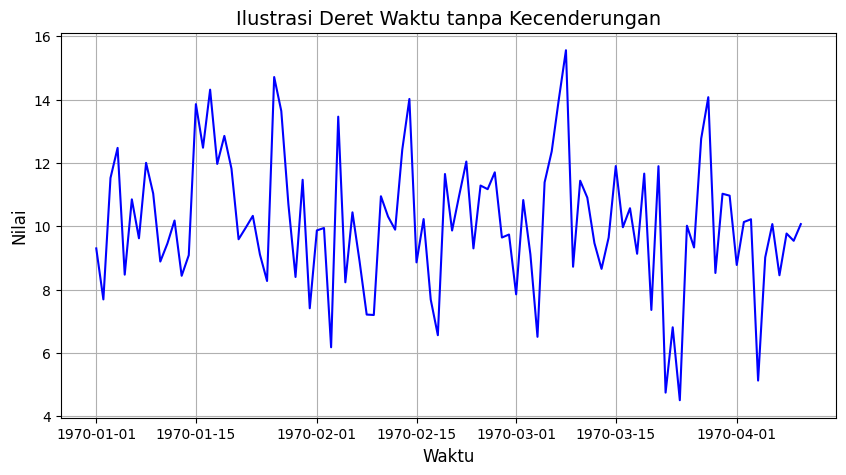

In [71]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

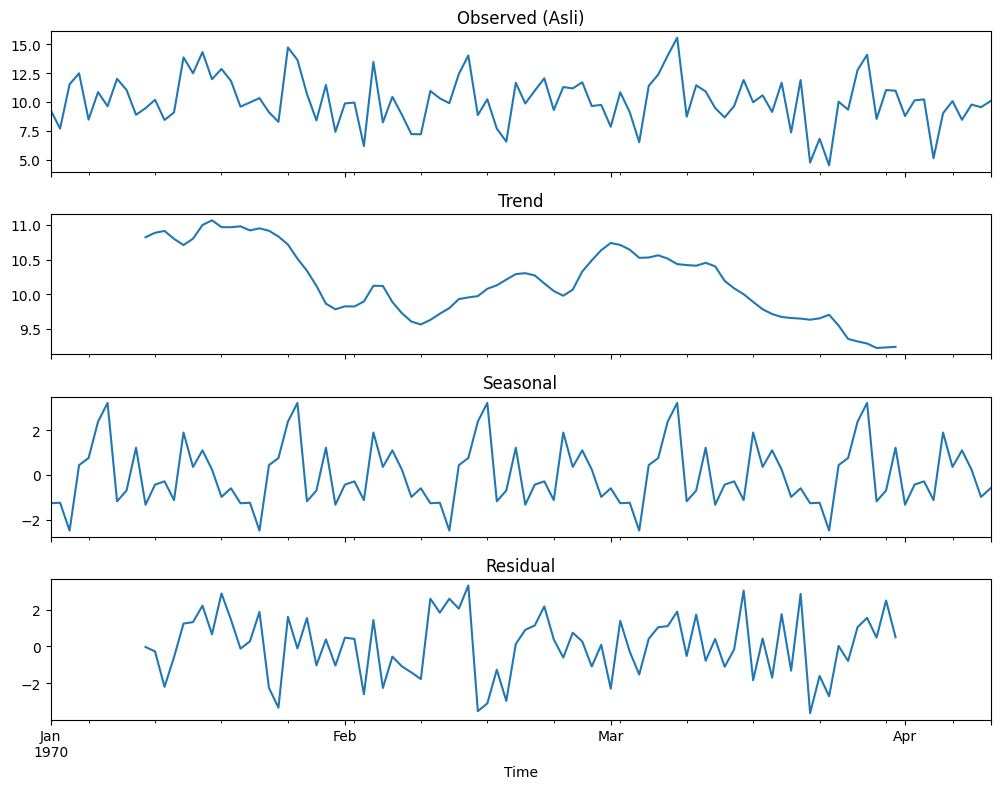

In [72]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi dari plot tersebut?**

Berdasarkan hasil dekomposisi, deret waktu terdiri dari beberapa komponen yaitu observed (data asli), tren, musiman, dan residual.

1. Komponen Tren (Trend)
menunjukkan perubahan yang relatif kecil dan tidak memiliki arah peningkatan atau penurunan yang konsisten. Hal ini menunjukkan bahwa data tidak memiliki kecenderungan jangka panjang yang kuat, sehingga variasi nilai lebih banyak berasal dari fluktuasi acak.
2. Komponen Musiman (Seasonal)
 menunjukkan adanya pola berulang pada periode tertentu, namun pola tersebut tidak menunjukkan pengaruh yang dominan terhadap data. Fluktuasi musiman yang terlihat lebih menggambarkan variasi periodik kecil dibandingkan pola musiman yang kuat.
 3. Komponen Residual (Noise)
menunjukkan variasi acak yang tersisa setelah komponen tren dan musiman dipisahkan. Residual berfluktuasi di sekitar nilai nol tanpa membentuk pola tertentu, yang menunjukkan bahwa sebagian besar perubahan data berasal dari faktor acak (noise).

**Kesimpulan:**

Hasil dekomposisi menunjukkan bahwa data tidak memiliki tren yang kuat dan pola musiman yang dominan. Variasi pada deret waktu lebih banyak dipengaruhi oleh komponen acak (noise). Oleh karena itu, model dekomposisi tren-musiman kurang memberikan informasi yang signifikan karena struktur utama data berasal dari proses acak.